In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [3]:
data = '''
# n_mol      AFQMC/CISD(Guide=HF)          AFQMC/stoCCSD(1)            AFQMC/stoCCSD(5)            AFQMC/stoCCSD(10)           AFQMC/stoCCSD(20)            AFQMC/stoCCSD(40)
    1       -1.096071 +/- 0.000000      -1.096071 +/- 0.000000      -1.096072 +/- 0.000000      -1.096072 +/- 0.000000      -1.096072 +/- 0.000000      -1.096072 +/- 0.000000
    2       -2.191880 +/- 0.000056      -2.192156 +/- 0.000282      -2.192051 +/- 0.000106      -2.192209 +/- 0.000077      -2.192144 +/- 0.000069      -2.192075 +/- 0.000043
    4       -4.383041 +/- 0.000197      -4.384630 +/- 0.001109      -4.384830 +/- 0.000639      -4.384307 +/- 0.000394      -4.384142 +/- 0.000370      -4.384625 +/- 0.000204
    8       -8.763738 +/- 0.000363      -8.761841 +/- 0.005470      -8.769022 +/- 0.001551      -8.766938 +/- 0.001133      -8.768361 +/- 0.000769      -8.769013 +/- 0.000499
    16      -17.524860 +/- 0.001137     -17.534499 +/- 0.009367     -17.540518 +/- 0.005201     -17.525354 +/- 0.005976     -17.532320 +/- 0.004061     -17.537668 +/- 0.002234
    32      -35.039686 +/- 0.002558     -35.080585 +/- 0.038454     -35.111957 +/- 0.016395     -35.092365 +/- 0.016328     -35.093822 +/- 0.011450     -35.091537 +/- 0.013604
    50      -54.728319 +/- 0.003216     -54.904226 +/- 0.075718     -54.783811 +/- 0.066186     -54.890955 +/- 0.032497     -54.777227 +/- 0.040944     -54.870165 +/- 0.016701
'''

In [4]:
n = []
afqmc_ci = []
afqmc_ci_err = []
afqmc_cc1 = []
afqmc_cc1_err = []
afqmc_cc5 = []
afqmc_cc5_err = []
afqmc_cc10 = []
afqmc_cc10_err = []
afqmc_cc20 = []
afqmc_cc20_err = []
afqmc_cc40 = []
afqmc_cc40_err = []
for lines in data.splitlines():
    if not lines.startswith('#') and len(lines) > 0:
        parts = lines.split()
        n = np.hstack((n,int(parts[0])))
        afqmc_ci = np.hstack((afqmc_ci,float(parts[1])/int(parts[0])))
        afqmc_ci_err = np.hstack((afqmc_ci_err,float(parts[3])/int(parts[0])))
        afqmc_cc1 = np.hstack((afqmc_cc1,float(parts[4])/int(parts[0])))
        afqmc_cc1_err = np.hstack((afqmc_cc1_err,float(parts[6])/int(parts[0])))
        afqmc_cc5 = np.hstack((afqmc_cc5,float(parts[7])/int(parts[0])))
        afqmc_cc5_err = np.hstack((afqmc_cc5_err,float(parts[9])/int(parts[0])))
        afqmc_cc10 = np.hstack((afqmc_cc10,float(parts[10])/int(parts[0])))
        afqmc_cc10_err = np.hstack((afqmc_cc10_err,float(parts[12])/int(parts[0])))
        afqmc_cc20 = np.hstack((afqmc_cc20,float(parts[13])/int(parts[0])))
        afqmc_cc20_err = np.hstack((afqmc_cc20_err,float(parts[15])/int(parts[0])))
        afqmc_cc40 = np.hstack((afqmc_cc40,float(parts[16])/int(parts[0])))
        afqmc_cc40_err = np.hstack((afqmc_cc40_err,float(parts[18])/int(parts[0])))

ref = np.array([-1.096072]*len(n))

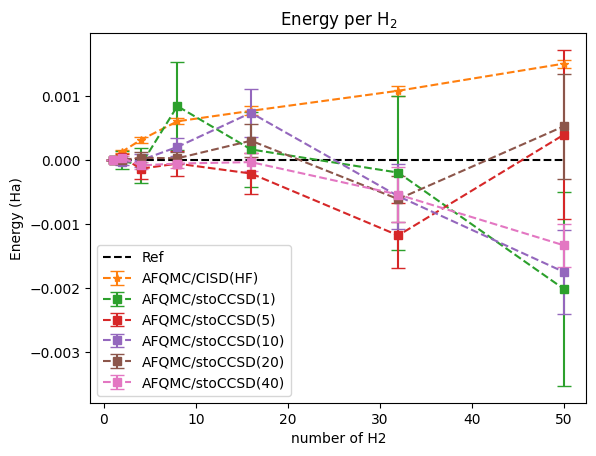

In [6]:
plt.errorbar(n,afqmc_ci-ref,yerr=afqmc_ci_err,fmt='*--', capsize=5, color='C1', label='AFQMC/CISD(HF)')
plt.errorbar(n,afqmc_cc1-ref,yerr=afqmc_cc1_err,fmt='s--', capsize=5, color='C2', label='AFQMC/stoCCSD(1)')
plt.errorbar(n,afqmc_cc5-ref,yerr=afqmc_cc5_err,fmt='s--', capsize=5, color='C3', label='AFQMC/stoCCSD(5)')
plt.errorbar(n,afqmc_cc10-ref,yerr=afqmc_cc10_err,fmt='s--', capsize=5, color='C4', label='AFQMC/stoCCSD(10)')
plt.errorbar(n,afqmc_cc20-ref,yerr=afqmc_cc20_err,fmt='s--', capsize=5, color='C5', label='AFQMC/stoCCSD(20)')
plt.errorbar(n,afqmc_cc40-ref,yerr=afqmc_cc40_err,fmt='s--', capsize=5, color='C6', label='AFQMC/stoCCSD(40)')
plt.plot(n,ref-ref,'--',color='black', label='Ref')
plt.xlabel('number of H2')
plt.ylabel('Energy (Ha)')
plt.title('Energy per H$_2$')
# handles, labels = plt.gca().get_legend_handles_labels()
# order = ['AFQMC/CISD(HF)', 'AFQMC/stoCCSD(1)', 'AFQMC/stoCCSD(5)', 'AFQMC/stoCCSD(10)', 'Ref']
# ordered_handles = [handles[labels.index(l)] for l in order]
# ordered_labels = order
# plt.legend(ordered_handles, ordered_labels)# bbox_to_anchor=(0.95, 0.5), loc='upper right')
plt.legend()
plt.show()

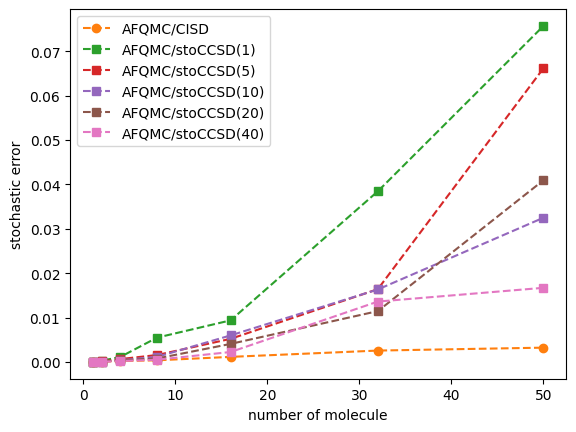

In [9]:
plt.plot(n, n*afqmc_ci_err, 'o--', color='C1', label='AFQMC/CISD')
plt.plot(n, n*afqmc_cc1_err, 's--', color='C2', label='AFQMC/stoCCSD(1)')
plt.plot(n, n*afqmc_cc5_err, 's--', color='C3', label='AFQMC/stoCCSD(5)')
plt.plot(n, n*afqmc_cc10_err, 's--', color='C4', label='AFQMC/stoCCSD(10)')
plt.plot(n, n*afqmc_cc20_err, 's--', color='C5', label='AFQMC/stoCCSD(20)')
plt.plot(n, n*afqmc_cc40_err, 's--', color='C6', label='AFQMC/stoCCSD(40)')
plt.ylabel('stochastic error')
plt.xlabel('number of molecule')
plt.legend()
plt.show()

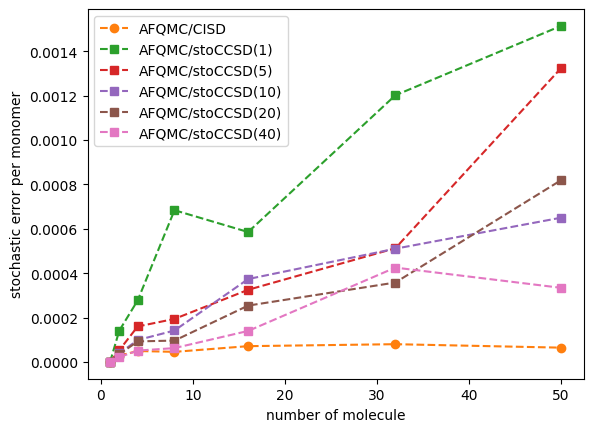

In [8]:
plt.plot(n, afqmc_ci_err, 'o--', color='C1', label='AFQMC/CISD')
plt.plot(n, afqmc_cc1_err, 's--', color='C2', label='AFQMC/stoCCSD(1)')
plt.plot(n, afqmc_cc5_err, 's--', color='C3', label='AFQMC/stoCCSD(5)')
plt.plot(n, afqmc_cc10_err, 's--', color='C4', label='AFQMC/stoCCSD(10)')
plt.plot(n, afqmc_cc20_err, 's--', color='C5', label='AFQMC/stoCCSD(20)')
plt.plot(n, afqmc_cc40_err, 's--', color='C6', label='AFQMC/stoCCSD(40)')
plt.ylabel('stochastic error per monomer')
plt.xlabel('number of molecule')
plt.legend()
plt.show()

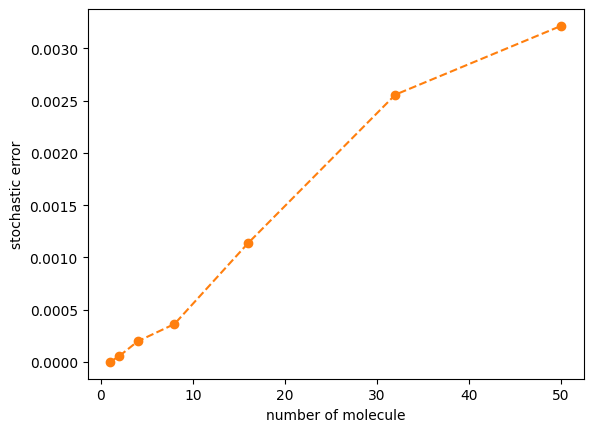

In [7]:
plt.plot(n, n*afqmc_ci_err, 'o--', color='C1', label='AFQMC/CISD')
plt.ylabel('stochastic error')
plt.xlabel('number of molecule')
plt.show()